# Stage A - Multinomial Logistic Regression from scratch
Baseline model for CIFAR-10 using flattened pixels.

In [7]:

import os, sys, subprocess
from pathlib import Path

REPO_URL = "https://github.com/a213696/Group-5-ML-Project.git"
REPO_NAME = "Group-5-ML-Project"

CURRENT = Path.cwd()

if (CURRENT / "src").exists():
    PROJECT_ROOT = CURRENT

elif CURRENT.name == "notebooks" and (CURRENT.parent / "src").exists():
    PROJECT_ROOT = CURRENT.parent

else:
    BASE_DIR = Path("/content") if Path("/content").exists() else CURRENT
    PROJECT_ROOT = BASE_DIR / REPO_NAME

    if not PROJECT_ROOT.exists():
        print("Cloning repository from GitHub...")
        subprocess.run(["git", "clone", REPO_URL, str(PROJECT_ROOT)], check=True)
    else:
        print("Repository already exists. Pulling latest version...")
        subprocess.run(["git", "-C", str(PROJECT_ROOT), "pull"], check=False)

os.chdir(PROJECT_ROOT)
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

FIG_DIR = PROJECT_ROOT / "artifacts" / "figures"
TABLE_DIR = PROJECT_ROOT / "artifacts" / "tables"
MODEL_DIR = PROJECT_ROOT / "artifacts" / "models"
for d in [FIG_DIR, TABLE_DIR, MODEL_DIR]:
    d.mkdir(parents=True, exist_ok=True)

print("Project root:", PROJECT_ROOT)
print("Current working directory:", Path.cwd())
print("src exists:", (PROJECT_ROOT / "src").exists())
print("notebooks exists:", (PROJECT_ROOT / "notebooks").exists())

if not (PROJECT_ROOT / "src").exists():
    raise FileNotFoundError("The src folder is missing. Upload src to GitHub or clone the full project repository, not only one notebook.")

import numpy as np, pandas as pd, json
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report
from src.data import get_preprocessed_flat, CLASSES, set_seeds
from src.logreg import SoftmaxRegression
from src.metrics import compute_metrics, classification_report_df, confusion_matrix_array, per_class_accuracy
from src import viz
set_seeds(42)



Project root: /content/Group-5-ML-Project
Current working directory: /content/Group-5-ML-Project
src exists: True
notebooks exists: False


In [8]:
(X_train, y_train), (X_val, y_val), (X_test, y_test), stats = get_preprocessed_flat()
print("X_train:", X_train.shape, "X_val:", X_val.shape, "X_test:", X_test.shape)
print("Model parameters:", X_train.shape[1] * 10 + 10)

X_train: (45000, 3072) X_val: (5000, 3072) X_test: (10000, 3072)
Model parameters: 30730


In [3]:

sample_size = min(10000, len(X_train))
rng = np.random.default_rng(42)
idx = rng.choice(len(X_train), sample_size, replace=False)
X_sub, y_sub = X_train[idx], y_train[idx]
search_space = [
    {"lr":0.1, "lam":0.0, "bs":128},
    {"lr":0.01, "lam":1e-4, "bs":128},
    {"lr":0.001, "lam":1e-4, "bs":64},
]
rows=[]
for hp in search_space:
    m = SoftmaxRegression(X_train.shape[1], 10, lr=hp["lr"], lam=hp["lam"], seed=42)
    hist = m.fit(X_sub, y_sub, X_val, y_val, batch_size=hp["bs"], max_epochs=25, patience=6, verbose=False)
    rows.append({**hp, "val_acc": max(hist["val_acc"])})
    print(hp, "val_acc=", round(max(hist["val_acc"]), 4))
search_df = pd.DataFrame(rows).sort_values("val_acc", ascending=False)
display(search_df)
search_df.to_csv(TABLE_DIR / "stageA_grid_search.csv", index=False)
best = search_df.iloc[0].to_dict()

{'lr': 0.1, 'lam': 0.0, 'bs': 128} val_acc= 0.2536
{'lr': 0.01, 'lam': 0.0001, 'bs': 128} val_acc= 0.3048
{'lr': 0.001, 'lam': 0.0001, 'bs': 64} val_acc= 0.37


,lr,lam,bs,val_acc
2,0.001,0.0001,64,0.3700
1,0.010,0.0001,128,0.3048
0,0.100,0.0000,128,0.2536


In [4]:
model = SoftmaxRegression(X_train.shape[1], 10, lr=float(best["lr"]), lam=float(best["lam"]), seed=42)
history = model.fit(X_train, y_train, X_val, y_val, batch_size=int(best["bs"]), max_epochs=80, patience=10, verbose=True)
y_pred = model.predict(X_test)
metrics = compute_metrics(y_test, y_pred, model_name="Logistic Regression (scratch)")
print(metrics)
report_df = classification_report_df(y_test, y_pred)
display(report_df)
report_df.to_csv(TABLE_DIR / "stageA_classification_report.csv")

Epoch   0 | train_loss=1.7709  val_loss=1.8306 | train_acc=0.3956  val_acc=0.3772
Epoch  10 | train_loss=1.6837  val_loss=1.8432 | train_acc=0.4236  val_acc=0.3754
Early stopping at epoch 12 (no improvement for 10 epochs)
{'model': 'Logistic Regression (scratch)', 'accuracy': 0.3901, 'macro_f1': 0.3824847157466994, 'weighted_f1': 0.38248471574669946}


,precision,recall,f1-score,support
airplane,0.4468,0.4580,0.4523,1000.0000
automobile,0.4599,0.4300,0.4444,1000.0000
bird,0.3057,0.2140,0.2518,1000.0000
cat,0.3141,0.2010,0.2451,1000.0000
deer,0.3710,0.3020,0.3330,1000.0000
dog,0.2937,0.2840,0.2888,1000.0000
frog,0.4030,0.4610,0.4300,1000.0000
horse,0.4399,0.4650,0.4521,1000.0000
ship,0.4717,0.5160,0.4928,1000.0000
truck,0.3510,0.5700,0.4345,1000.0000


Saved → /content/Group-5-ML-Project/src/../artifacts/figures/stageA_loss_curves.png


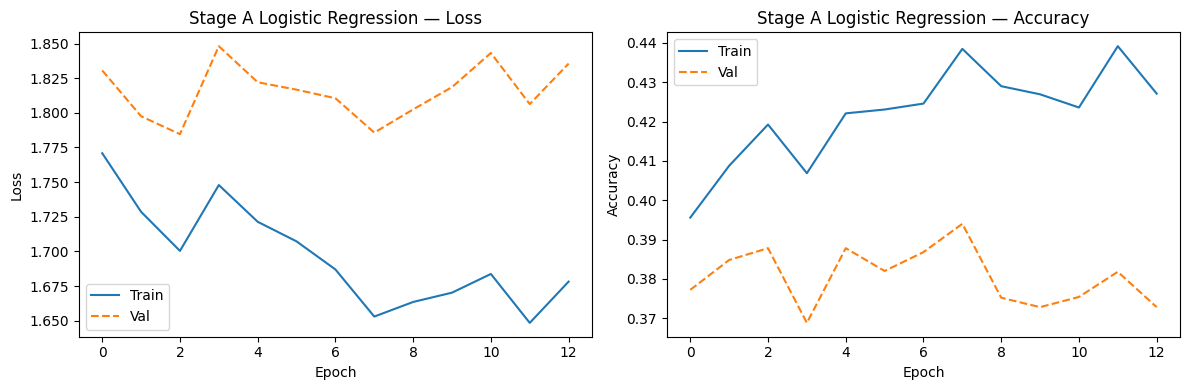

Saved → /content/Group-5-ML-Project/src/../artifacts/figures/stageA_confusion_matrix.png


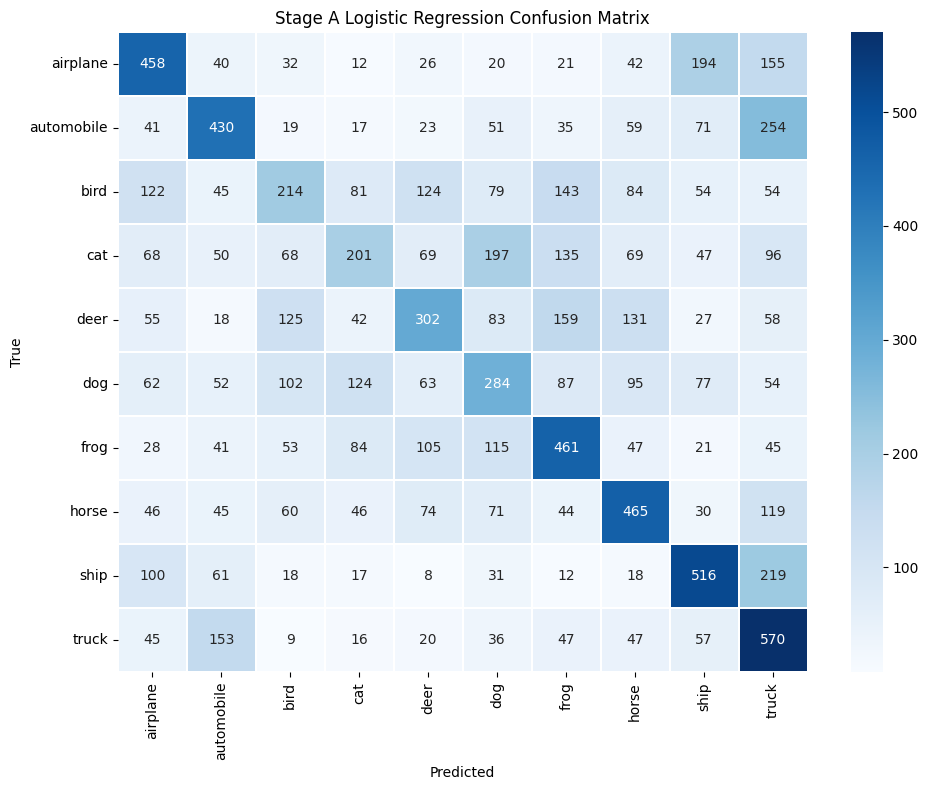

In [5]:
viz.plot_loss_curves(history, title="Stage A Logistic Regression", save_name="stageA_loss_curves.png")
cm = confusion_matrix_array(y_test, y_pred)
viz.plot_confusion_matrix(cm, title="Stage A Logistic Regression Confusion Matrix", save_name="stageA_confusion_matrix.png")

In [6]:
result_record = {
    "model": "Logistic Regression (scratch)",
    "stage": "A",
    "hyperparameters": {"lr": float(best["lr"]), "lam": float(best["lam"]), "batch_size": int(best["bs"])},
    "n_params": int(X_train.shape[1] * 10 + 10),
    "test_accuracy": float(metrics["accuracy"]),
    "macro_f1": float(metrics["macro_f1"]),
    "weighted_f1": float(metrics["weighted_f1"]),
}
with open(TABLE_DIR / "stageA_result.json", "w") as f: json.dump(result_record, f, indent=2)
print("Stage A result saved.")

Stage A result saved.


## Stage A interpretation
Logistic regression is a useful baseline because it is simple and explains what can be learned from flattened pixel values only. It performs above the 10 percent random baseline, but it is limited because it uses a linear decision boundary and does not know which pixels are neighbours. This is why visually similar classes such as cat, dog, deer, and horse are expected to be confused.